# Integración de las tres capas (segunda versión)

Verificación y tablas de apoyo del cruce de la **Capa 1** (contexto y necesidades), la **Capa 2** (intereses,
hábitos y barreras) y la **Capa 3** (oferta y convocatoria). La lectura principal está en
`resultados/informe_final.md`; el método, en `fuentes/metodologia_integracion.md`; el diagnóstico que motivó esta
versión, en `fuentes/auditoria_integracion.md`.

Este notebook:

1. reconstruye las tablas de `resultados/` desde los datos y comprueba que coinciden con las guardadas;
2. muestra las validaciones de las estimaciones nuevas frente a Dato Joven;
3. verifica la trazabilidad y las reglas del cruce;
4. compara las bases de población y muestra el tamaño de los segmentos;
5. presenta el mapa de evidencia de las fichas (**no es un ranking**), que son alternativas derivadas de evidencia
   secundaria: su participación concreta se validará con jóvenes en una fase posterior;
6. resume el contexto por distrito (criterio operativo, no de demanda).

In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 110); pd.set_option("display.width", 220); pd.set_option("display.max_rows", 250)
RAIZ = Path("..").resolve()
sys.path.insert(0, str(RAIZ / "scripts"))
import os; os.chdir(RAIZ)  # los scripts leen rutas relativas a la carpeta del proyecto

AZUL, NARANJA, TINTA, TINTA_2, GRILLA, EJE, FONDO = "#2a78d6", "#c8641e", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "axes.edgecolor": EJE, "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": TINTA_2, "ytick.color": TINTA_2, "font.size": 9.5, "figure.dpi": 110,
})
R = RAIZ / "resultados"
P = RAIZ / "data" / "processed"
TABLAS = ["evidencias", "hallazgos_integrados", "patrones", "segmentos", "fichas_actividad", "fichas_cadena",
          "fichas_componentes", "fichas_convocatoria", "cambios_primera_version"]
guardadas = {n: pd.read_csv(R / f"{n}.csv") for n in TABLAS}
reg = pd.read_csv(RAIZ / "fuentes" / "capa3_registro_oferta.csv")
print({n: len(t) for n, t in guardadas.items()})

{'evidencias': 217, 'hallazgos_integrados': 62, 'patrones': 13, 'segmentos': 18, 'fichas_actividad': 15, 'fichas_cadena': 150, 'fichas_componentes': 32, 'fichas_convocatoria': 32, 'cambios_primera_version': 12}


## 1. Reconstrucción reproducible

`integracion_construir.construir()` vuelve a leer los datos procesados, reemplaza los marcadores de los textos y
aplica todas las reglas (se detiene con un error si alguna falla). Las tablas resultantes deben ser iguales a las
guardadas en `resultados/`.

In [2]:
import io
import integracion_construir as IC

nuevas = IC.construir()
for n in TABLAS:
    # la tabla reconstruida pasa por el mismo formato CSV que la guardada antes de compararlas
    buf = io.StringIO(); nuevas[n].to_csv(buf, index=False); buf.seek(0)
    try:
        pd.testing.assert_frame_equal(pd.read_csv(buf), guardadas[n], check_exact=False, rtol=1e-9)
        resultado = "igual"
    except AssertionError as ex:
        resultado = "DISTINTA: " + str(ex).splitlines()[0]
    print(f"{n:26} {resultado}")

evidencias                 igual
hallazgos_integrados       igual
patrones                   igual
segmentos                  igual
fichas_actividad           igual
fichas_cadena              igual
fichas_componentes         igual
fichas_convocatoria        igual
cambios_primera_version    igual


### 1.1 Controles de consistencia

Controles automáticos entre tablas (ver `fuentes/metodologia_integracion.md` §11). Deben pasar todos.

In [3]:
val = IC.validar(nuevas)
display(val)
assert (val.resultado == "ok").all(), "Hay controles de consistencia que fallan"

,control,resultado,detalle
0,Convocatoria de la ficha = máximo de sus registros comparables,ok,
1,Alcance 'amplia' solo con evidencia sobre toda la juventud y con cantidades,ok,
2,"Sin lenguaje de ranking, 'baja convocatoria' o demanda generalizada",ok,
3,Las afirmaciones no atribuyen intención de participar,ok,
4,"C0 se presenta como ausencia de evidencia, no como resultado negativo",ok,
5,Estados de componentes coherentes con las dimensiones de la ficha,ok,
6,Toda evidencia citada tiene ámbito y periodo,ok,
7,Cantidades estimadas solo a partir de porcentajes de un grupo de población,ok,
8,Cada actividad de convocatoria explicita su salto inferencial y sus hipótesis,ok,
9,Protocolos y poblaciones a consultar sin código de convocatoria,ok,


## 2. Validaciones de las estimaciones nuevas

### 2.1 Situación de estudio y trabajo (ENAHO) frente a Dato Joven

Réplica de "Actividades que realizan los jóvenes" para Lima Metropolitana, 2022–2025, total y por sexo. Tolerancia:
±1 punto (la misma de la decisión D15 de la Capa 1).

In [4]:
v = pd.read_csv(P / "integracion_enaho_validacion.csv")
display(v.groupby(["categoria_proyecto", "categoria_dato_joven"]).agg(
    comparaciones=("diferencia", "size"), dentro_de_1_punto=("dentro_tolerancia", "sum"),
    diferencia_maxima=("diferencia", lambda s: round(s.abs().max(), 2)),
    diferencia_media=("diferencia", lambda s: round(s.mean(), 2))))
display(v[v.categoria_proyecto == "ni_estudia_ni_trabaja"].round(2))

,,comparaciones,dentro_de_1_punto,diferencia_maxima,diferencia_media
categoria_proyecto,categoria_dato_joven,,,,
estudia_y_trabaja,TRABAJA Y ESTUDIA,12,12,0.08,-0.04
ni_estudia_ni_trabaja,NINI,12,6,1.92,1.16
solo_estudia,SOLO ESTUDIA,12,12,0.21,0.01
solo_trabaja,SOLO TRABAJA,12,3,2.05,-1.17


,anio,sexo,categoria_dato_joven,categoria_proyecto,valor_proyecto,valor_dato_joven,diferencia,dentro_tolerancia
3,2022,total,NINI,ni_estudia_ni_trabaja,21.83,20.2,1.63,False
7,2022,hombre,NINI,ni_estudia_ni_trabaja,16.02,14.1,1.92,False
11,2022,mujer,NINI,ni_estudia_ni_trabaja,27.65,26.4,1.25,False
15,2023,total,NINI,ni_estudia_ni_trabaja,20.58,19.6,0.98,True
19,2023,hombre,NINI,ni_estudia_ni_trabaja,16.75,15.5,1.25,False
23,2023,mujer,NINI,ni_estudia_ni_trabaja,24.36,23.6,0.76,True
27,2024,total,NINI,ni_estudia_ni_trabaja,19.40,18.3,1.10,False
31,2024,hombre,NINI,ni_estudia_ni_trabaja,15.19,13.8,1.39,False
35,2024,mujer,NINI,ni_estudia_ni_trabaja,23.53,22.7,0.83,True
39,2025,total,NINI,ni_estudia_ni_trabaja,18.86,17.9,0.96,True


"Estudia y trabaja" y "solo estudia" son equivalentes. "No estudia ni trabaja" y "solo trabaja" no lo son: la
definición del proyecto da ~1 punto más de jóvenes que no estudian ni trabajan (desocupados ocultos y casos sin dato
de empleo, cuyo tratamiento en Dato Joven no se pudo confirmar porque sus manuales ahora exigen iniciar sesión). Por
eso esa categoría se llama "no estudia ni trabaja (definición del proyecto)" y **no se compara con la cifra "NINI" de
Dato Joven** (decisión I2-D3).

### 2.2 Seguridad (ENAPRES) frente a Dato Joven

In [5]:
s = pd.read_csv(P / "integracion_seguridad_enapres_validacion.csv")
display(s.round(2))
print(f"Dentro de ±1 punto: {s.dentro_tolerancia.sum()} de {len(s)}; diferencia máxima: {s.diferencia.abs().max():.2f}")

,indicador,anio,sexo,valor_proyecto,valor_dato_joven,diferencia,dentro_tolerancia
0,noche_inseguro,2022,total,64.77,65.0,-0.23,True
1,noche_inseguro,2022,hombre,55.06,55.3,-0.24,True
2,noche_inseguro,2022,mujer,74.40,74.5,-0.10,True
3,noche_inseguro,2023,total,59.13,59.5,-0.37,True
4,noche_inseguro,2023,hombre,47.35,47.9,-0.55,True
5,noche_inseguro,2023,mujer,70.89,71.0,-0.11,True
6,noche_inseguro,2024,total,61.04,61.0,0.04,True
7,noche_inseguro,2024,hombre,50.75,50.7,0.05,True
8,noche_inseguro,2024,mujer,72.18,72.3,-0.12,True
9,noche_inseguro,2025,total,58.29,58.4,-0.11,True


Dentro de ±1 punto: 15 de 15; diferencia máxima: 0.55


### 2.3 Controles internos de la ENUT y la ENAPRES

Las funciones nuevas reproducen los valores ya publicados en la Capa 2.

In [6]:
c2 = pd.read_csv(P / "capa2_uso_tiempo_enut.csv")
t = pd.read_csv(P / "integracion_tiempo_enut.csv")
x = t[(t.indicador == "participacion_semanal") & (t.grupo == "todos") & (t.grupo_edad == "15-29")]
y = c2[(c2.familia == "participacion_semanal") & (c2.grupo_edad == "15-29")]
comp = x.merge(y, on=["nivel_geografico", "sexo", "categoria"], suffixes=("_integracion", "_capa2"))
comp["diferencia"] = (comp.valor_integracion - comp.valor_capa2).round(3)
display(comp[["nivel_geografico", "sexo", "categoria", "valor_integracion", "valor_capa2", "diferencia"]])
print("Diferencia máxima (puntos):", comp.diferencia.abs().max())

,nivel_geografico,sexo,categoria,valor_integracion,valor_capa2,diferencia
0,lima_metropolitana,total,Deporte y ejercicio físico,34.847,34.847,0.0
1,lima_metropolitana,total,Voluntariado y ayuda a la comunidad u otros hogares,5.606,5.606,0.0
2,lima_metropolitana,total,Leer,10.361,10.361,0.0
3,lima_metropolitana,total,"Aficiones, artes y juegos",18.314,18.314,0.0
4,lima_metropolitana,total,"Asistir a eventos culturales, de entretenimiento o deportivos",21.927,21.927,0.0
5,lima_metropolitana,total,Cuidado de otras personas del hogar,46.167,46.167,0.0
6,lima_metropolitana,hombre,Deporte y ejercicio físico,49.137,49.137,0.0
7,lima_metropolitana,hombre,Voluntariado y ayuda a la comunidad u otros hogares,5.377,5.377,0.0
8,lima_metropolitana,hombre,Leer,12.138,12.138,0.0
9,lima_metropolitana,hombre,"Aficiones, artes y juegos",26.997,26.997,0.0


Diferencia máxima (puntos): 0.0


## 3. Trazabilidad y reglas

- Cada evidencia citada existe y ninguna cifra no publicable aparece en un texto (lo aplica el constructor).
- Cada actividad de la Capa 3 citada existe en el registro, y el nombre guardado en `fichas_convocatoria.csv`
  coincide con el del registro.
- Los patrones citan hallazgos existentes.
- Ningún texto tiene porcentajes escritos a mano (lo aplica el constructor).

In [7]:
ev, hall, pat = guardadas["evidencias"], guardadas["hallazgos_integrados"], guardadas["patrones"]
fichas, conv = guardadas["fichas_actividad"], guardadas["fichas_convocatoria"]
ids = lambda s: {x.strip() for v in s.dropna() for x in str(v).split(";") if x.strip()}
citadas = ids(hall.evidencias) | ids(pat.evidencias) | ids(fichas.evidencias)
print("Evidencias citadas que no existen:", citadas - set(ev.id) or "ninguna")
print("Evidencias no publicables citadas:", set(ev[ev.precision == "no_publicable"].id) & citadas or "ninguna")
c3_citadas = ids(hall.actividades_c3) | ids(fichas.actividades_c3)
print("Actividades de la Capa 3 citadas que no existen:", c3_citadas - set(reg.id) or "ninguna")
nombres = conv.merge(reg[["id", "nombre"]], left_on="actividad_c3", right_on="id", suffixes=("", "_registro"))
print("Nombres que no coinciden con el registro:", int((nombres.nombre != nombres.nombre_registro).sum()))
print("Hallazgos citados por patrones que no existen:", ids(pat.hallazgos) - set(hall.id) or "ninguno")
print(f"Evidencias en el registro: {len(ev)}; citadas en algún texto: {int((ev.citada_en == 'sí').sum())}")
display(ev.groupby(["naturaleza", "precision"]).size().unstack(fill_value=0))

Evidencias citadas que no existen: ninguna
Evidencias no publicables citadas: ninguna
Actividades de la Capa 3 citadas que no existen: ninguna
Nombres que no coinciden con el registro: 0
Hallazgos citados por patrones que no existen: ninguno
Evidencias en el registro: 217; citadas en algún texto: 209


precision,confiable,conteo,no aplica,referencial,sin error publicado
naturaleza,,,,,
cobertura de fuentes,0,2,0,0,0
encuesta representativa,147,0,3,16,0
estudio de mercado (orientativo),0,0,0,0,5
oferta publicada,0,16,0,0,0
registro administrativo,0,10,8,0,0
registro de autoselección (señal),0,10,0,0,0


### 3.1 Estado de los hallazgos frente a la primera versión

In [8]:
display(hall.groupby(["capa", "estado_v2"]).size().unstack(fill_value=0))
display(hall[hall.estado_v2 != "sin cambios"][["id", "estado_v2", "cambio_v2"]])

estado_v2,ampliado,corregido,nuevo,reemplazado,sin cambios
capa,,,,,
1,2,4,6,5,3
2,2,6,6,0,7
3,0,0,2,0,19


,id,estado_v2,cambio_v2
0,H1-01,ampliado,Se agregan las bases de población de las encuestas y se explica por qué difieren.
1,H1-02,corregido,La primera versión decía que ninguna era de participación y ciudadanía; la categoría 'Otros' ocultaba 7 de...
3,H1-04,reemplazado,"Compara con Lima Este (antes, con Lima Metropolitana)."
4,H1-05,reemplazado,Reemplaza indicadores de Lima Metropolitana por estimaciones de Lima Este.
5,H1-06,reemplazado,Reemplaza cifras de Lima Metropolitana por estimaciones de Lima Este.
6,H1-07,reemplazado,Estimación de Lima Este; antes solo había Lima Metropolitana.
7,H1-08,corregido,El dato de hombres es referencial (antes figuraba como confiable).
8,H1-09,corregido,Ya no se usa como evidencia de necesidad.
9,H1-10,reemplazado,"Estimación propia de Lima Este con la ENAPRES, validada con Dato Joven (antes, Lima Metropolitana)."
10,H1-11,corregido,Se agrega la advertencia sobre la variabilidad de la serie.


## 4. Bases de población

Las encuestas del INEI estiman para Lima Este un total de jóvenes distinto del de Dato Joven (proyección 2026). Sus
factores de expansión no se calibran por distrito, y la proyección de Dato Joven es inestable por edad (D5). Por eso
las cantidades se dan con las dos bases y no se combinan (decisión I2-D6).

,fuente,poblacion,ee,ic95
0,Dato Joven 2026 (REUNIS/INEI),712000.0,NaN,NaN
1,ENAHO 2022–2025,848000.0,41468.0,81000.0
2,ENAPRES 2022–2025 (800A),677000.0,39248.0,77000.0
3,ENUT 2024,558000.0,80367.0,158000.0


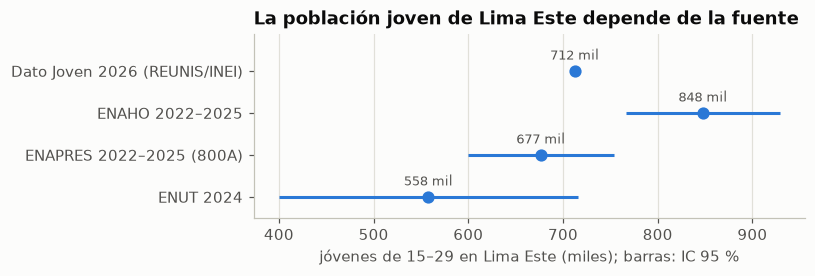

In [9]:
bases = pd.DataFrame([
    {"fuente": "Dato Joven 2026 (REUNIS/INEI)", "poblacion": ev.set_index("id").loc["E-001", "valor"], "ee": np.nan},
    *[{"fuente": f, "poblacion": ev.set_index("id").loc[i, "valor"], "ee": ev.set_index("id").loc[i, "ee"]}
      for f, i in [("ENAHO 2022–2025", "E-007"), ("ENAPRES 2022–2025 (800A)", "E-008"), ("ENUT 2024", "E-009")]]])
bases["ic95"] = (1.96 * bases.ee).round(-3)
display(bases.assign(poblacion=bases.poblacion.round(-3)))

fig, ax = plt.subplots(figsize=(7.5, 2.6))
y = np.arange(len(bases))[::-1]
ax.errorbar(bases.poblacion / 1000, y, xerr=bases.ic95.fillna(0) / 1000, fmt="o", color=AZUL, ecolor=AZUL,
            elinewidth=2, capsize=0, markersize=7)
for yi, (p, f) in zip(y, zip(bases.poblacion, bases.fuente)):
    ax.text(p / 1000, yi + 0.28, f"{p / 1000:,.0f} mil".replace(",", " "), ha="center", fontsize=8.5, color=TINTA_2)
ax.set_ylim(-0.5, len(bases) - 0.1); ax.set_yticks(y, bases.fuente); ax.set_xlabel("jóvenes de 15–29 en Lima Este (miles); barras: IC 95 %")
ax.grid(axis="x", color=GRILLA); ax.set_axisbelow(True); ax.spines[["top", "right"]].set_visible(False)
ax.set_title("La población joven de Lima Este depende de la fuente")
plt.tight_layout(); plt.show()

## 5. Segmentos: tamaño con las dos bases

Cada segmento se da en porcentaje (con IC 95 %) y en personas: el porcentaje aplicado a la población 2026 de Dato
Joven y el total que estima la propia encuesta. El tamaño **no se convierte en importancia ni en recomendación**.

,id,segmento,porcentaje,ic95_inf,ic95_sup,precision,personas_base_dato_joven_inf,personas_base_dato_joven_sup,personas_encuesta,personas_encuesta_ic95,fichas
0,S-01,Jóvenes de 15–24 que no estudian y cuyo nivel máximo es secundaria completa,29.0,26.7,31.2,confiable,119000.0,140000.0,157000.0,20000.0,F-01
1,S-02,"Ídem, con problemas económicos como motivo principal",9.8,8.2,11.4,confiable,36000.0,51000.0,53000.0,10000.0,F-01
2,S-03,Jóvenes sin trabajo que buscan o quieren trabajar,11.4,10.1,12.7,confiable,72000.0,91000.0,97000.0,15000.0,F-02
3,S-04,Jóvenes que buscan trabajo (desocupados),5.8,4.8,6.8,confiable,34000.0,48000.0,49000.0,10000.0,F-02
4,S-05,Jóvenes ocupados con empleo informal (2022–2023),37.6,34.5,40.7,confiable,246000.0,290000.0,301000.0,50000.0,F-03
5,S-06,Jóvenes que trabajan por cuenta propia o como empleadores,9.9,8.7,11.1,confiable,62000.0,79000.0,84000.0,13000.0,F-04
6,S-07,Jóvenes que hicieron deporte o ejercicio en la semana,27.6,20.6,34.6,confiable,147000.0,247000.0,154000.0,55000.0,F-05
7,S-08,Jóvenes que fueron a un festival local o tradicional en el año,19.6,16.2,23.0,confiable,115000.0,164000.0,133000.0,27000.0,F-06
8,S-09,Jóvenes que fueron a un concierto o festival musical en el año,21.4,18.0,24.8,confiable,128000.0,176000.0,145000.0,28000.0,F-06
9,S-10,Jóvenes que fueron al cine en el año,63.2,59.2,67.2,confiable,422000.0,478000.0,427000.0,57000.0,F-07


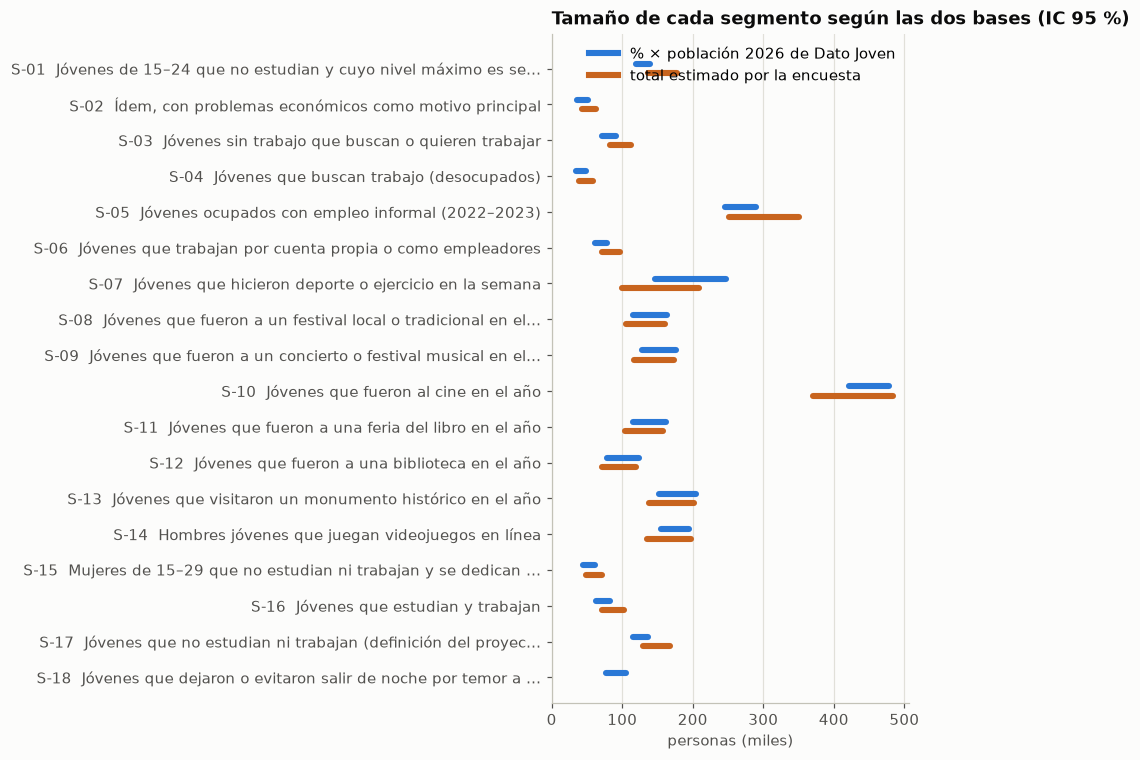

In [10]:
seg = guardadas["segmentos"]
display(seg[["id", "segmento", "porcentaje", "ic95_inf", "ic95_sup", "precision", "personas_base_dato_joven_inf",
             "personas_base_dato_joven_sup", "personas_encuesta", "personas_encuesta_ic95", "fichas"]])

s = seg.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.5, 7))
for i, r in s.iterrows():
    if pd.notna(r.personas_base_dato_joven_inf):
        ax.plot([r.personas_base_dato_joven_inf / 1000, r.personas_base_dato_joven_sup / 1000], [i + 0.13] * 2,
                color=AZUL, lw=4, solid_capstyle="round")
    if pd.notna(r.personas_encuesta):
        lo, hi = (r.personas_encuesta - r.personas_encuesta_ic95) / 1000, (r.personas_encuesta + r.personas_encuesta_ic95) / 1000
        ax.plot([lo, hi], [i - 0.13] * 2, color=NARANJA, lw=4, solid_capstyle="round")
ax.set_yticks(range(len(s)), [f"{r.id}  {r.segmento[:58]}{'…' if len(r.segmento) > 58 else ''}" for r in s.itertuples()])
ax.set_xlabel("personas (miles)")
ax.plot([], [], color=AZUL, lw=4, label="% × población 2026 de Dato Joven")
ax.plot([], [], color=NARANJA, lw=4, label="total estimado por la encuesta")
ax.legend(loc="upper right", frameon=False); ax.set_xlim(left=0)
ax.grid(axis="x", color=GRILLA); ax.set_axisbelow(True); ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Tamaño de cada segmento según las dos bases (IC 95 %)")
plt.tight_layout(); plt.show()

Las encuestas de seguridad (S-18) no tienen estimación propia de personas: los factores del capítulo no expanden a
totales coherentes (decisión I2-D8).

## 6. Mapa de evidencia de las fichas

Una fila por ficha, en orden temático. **No es un ranking:** las columnas no se suman ni se comparan entre filas, y
los códigos son categorías descriptivas (ver `fuentes/metodologia_integracion.md` §4).

In [11]:
display(fichas[["id", "linea", "actividad", "tipo_ficha", "necesidad_tipo", "interes_codigo", "alcance_tipo",
                "convocatoria_codigo", "convocatoria_detalle_codigo"]])

,id,linea,actividad,tipo_ficha,necesidad_tipo,interes_codigo,alcance_tipo,convocatoria_codigo,convocatoria_detalle_codigo
0,F-01,Educación y acceso a estudios superiores,Preparación gratuita para el ingreso a la educación superior,intervención segmentada,brecha de acceso,P0,segmento identificable,C4,"C4 por C3-125: comparable en todas las dimensiones. Es demanda por esa oferta concreta, no interés general..."
1,F-02,Empleo e ingresos,Acompañamiento para la búsqueda de empleo (preparación y conexión con vacantes),intervención segmentada,prevalencia,P1,segmento identificable,C4,"C4 por C3-084: comparable en parte; no plenamente en territorio, formato. Es demanda por esa oferta concre..."
2,F-03,Empleo e ingresos,Derechos laborales y formalización para jóvenes que ya trabajan,intervención segmentada,prevalencia,P0,segmento identificable,C2,C2 por C3-061: comparable en todas las dimensiones
3,F-04,Empleo e ingresos,Apoyo a jóvenes que ya trabajan por cuenta propia,intervención segmentada,sin evidencia,P1,segmento identificable,C2,C2 por C3-132: comparable en parte; no plenamente en formato
4,F-05,Deporte y actividad física,"Deporte organizado para jóvenes de 18–29 (ligas, torneos, entrenamiento)",actividad de convocatoria abierta,sin evidencia,P1,amplia,C3,"C3 por C3-053: comparable en parte; no plenamente en costo. Cifra declarada por quien organiza, sin cupos ..."
5,F-06,Cultura y encuentro,"Festival o escenario local gratuito (música, danza y fiestas locales)",actividad de convocatoria abierta,sin evidencia,P2,amplia,C2,C2 por C3-035: comparable en parte; no plenamente en formato
6,F-07,Cultura y encuentro,Proyecciones de cine gratuitas,actividad de convocatoria abierta,sin evidencia,P1,amplia,C0,NaN
7,F-08,Cultura y encuentro,Actividades juveniles en ferias del libro y bibliotecas,actividad de convocatoria abierta,sin evidencia,P2,amplia,C2,"C2 por C3-107: comparable en parte; no plenamente en segmento, formato"
8,F-09,Cultura y encuentro,Visitas y rutas de patrimonio cultural,actividad de convocatoria abierta,sin evidencia,P2,amplia,C2,C2 por C3-019: comparable en parte; no plenamente en segmento
9,F-10,Cultura digital,Encuentros o torneos presenciales de videojuegos,actividad de convocatoria abierta,sin evidencia,P1,segmento identificable,C0,NaN


In [12]:
comp = guardadas["fichas_componentes"]
display(pd.crosstab(comp.ficha, comp.estado))

estado,complementario (ya existe),condición transversal,descartado,hipótesis de diseño,respaldado en dos o más dimensiones,respaldado en una dimensión,sin evidencia,solo señales débiles
ficha,,,,,,,,
F-01,0,0,0,0,2,0,1,0
F-02,1,0,1,0,1,0,0,0
F-03,0,0,0,0,0,1,0,0
F-04,0,0,1,0,0,1,1,0
F-05,0,0,0,1,1,0,0,0
F-06,0,0,0,0,0,1,2,0
F-07,0,0,0,0,0,1,2,0
F-08,0,0,0,0,0,2,0,0
F-09,0,0,0,0,0,1,0,0


### 6.1 Convocatoria: cómo se calculó cada código

El código depende del tipo de evidencia del registro de la Capa 3 y de la comparabilidad declarada. Los registros "no
comparables" (segmento o territorio distintos) se muestran pero no definen el código.

In [13]:
display(conv[["ficha", "actividad_c3", "nombre", "evidencia_c3", "cifra_declarada", "comparable_segmento",
              "comparable_territorio", "comparable_formato", "comparable_costo", "codigo"]])

,ficha,actividad_c3,nombre,evidencia_c3,cifra_declarada,comparable_segmento,comparable_territorio,comparable_formato,comparable_costo,codigo
0,F-01,C3-070,Academia Preuniversitaria Municipal CEPREMUNI,participación declarada,180.0,sí,sí,sí,sí,C3
1,F-01,C3-046,Muni Becas: becas de preparación preuniversitaria,participación declarada,100.0,sí,sí,parcial,sí,C3
2,F-01,C3-125,Concursos de becas de CEPREMUNI (Santa Anita),demanda observada,80.0,sí,sí,sí,sí,C4
3,F-01,C3-123,Academia Preuniversitaria Municipal CEPREMUNI (Santa Anita),participación declarada,NaN,sí,sí,sí,no,C2
4,F-01,C3-080,Feria de Orientación Vocacional,participación declarada,300.0,parcial,sí,parcial,sí,C2
5,F-02,C3-003,Programa municipal 'Mi Primera Chamba',participación declarada,143.0,sí,sí,parcial,sí,C3
6,F-02,C3-090,"Programa 'Habilidades socioemocionales, empleabilidad y desarrollo personal' en el CEBA Antenor Orrego",participación declarada,62.0,sí,sí,sí,sí,C3
7,F-02,C3-094,Jóvenes Productivos: capacitación dual e inserción en empresas textiles de SJL,participación declarada,50.0,sí,sí,parcial,sí,C3
8,F-02,C3-084,"Talleres juveniles: arte, desarrollo y empleabilidad (verano 2024), sede presencial en SJL",demanda observada,5000.0,sí,parcial,parcial,sí,C4
9,F-02,C3-102,"Ferias y bolsas de empleo (Feria del Empleo 2025, bolsa de trabajo en Mall Aventura, Gran Registratón Labo...",participación declarada,NaN,no,sí,parcial,sí,no comparable


### 6.2 Una ficha completa (ejemplo: F-15)

La ficha de las mujeres jóvenes dedicadas al hogar no propone ninguna actividad: caracteriza el segmento y deja
explícito qué no sabemos.

In [14]:
cad = guardadas["fichas_cadena"]
for r in cad[cad.ficha == "F-15"].itertuples():
    print(f"{r.orden}. {r.paso} [{r.codigo if isinstance(r.codigo, str) else ''}]\n   {r.texto}\n")

1. Contexto o necesidad [situación documentada]
   14,0 % de las mujeres de 15–29 no estudia ni trabaja y se dedica al hogar; entre los hombres, 3,8 %. Es la situación principal de las mujeres que no estudian ni trabajan (62,4 %).

2. Población a la que aplica []
   ≈ 45–61 mil según la población 2026 de Dato Joven; 49–71 mil según la expansión de la encuesta. Es más frecuente a los 25–29 (17,9 % de las mujeres de esa edad) que a los 15–19 (8,0 % (referencial)). De ellas, 46,8 % tiene 25–29 años; 53,3 % está en unión (frente a 13,1 % de las demás mujeres); 57,9 % vive con niños de 0 a 5 años (frente a 29,4 %); 37,8 % es jefa de hogar o pareja del jefe y 46,1 % es hija; 84,0 % tiene secundaria completa.

3. Interés o práctica observada [P0]
   [P0] No sabemos qué actividades les interesan. 93,9 % usó internet el mes anterior, pero solo 16,6 % (referencial) lo usa para aprender (frente a 38,1 % de las demás mujeres); 20,8 % (referencial) quería trabajar.

4. Alcance potencial [segmento i

## 7. Contexto por distrito

Reúne los datos distritales de la Capa 1 y la cobertura de la Capa 3. **No es un ranking de prioridad ni de
interés**: las encuestas no tienen muestra por distrito, las tasas de los registros dependen del acceso a los
servicios y las actividades registradas dependen de cuánto publica cada municipalidad. Sirve para el criterio
operativo de dónde pilotear (I-R7).

In [15]:
DISTRITOS = ["Ate", "Chaclacayo", "El Agustino", "La Molina", "Lurigancho-Chosica", "San Juan de Lurigancho", "Santa Anita"]
pob = pd.read_csv(P / "capa1_poblacion_resumen.csv")
pob = pob[(pob.anio == 2026) & (pob.lima_este == True)].set_index("distrito")
renoj = pd.read_csv(P / "capa1_renoj_resumen_distritos.csv").set_index("distrito")
vol = pd.read_csv(P / "capa1_voluntariado_resumen_distritos.csv").set_index("distrito")
regs = pd.read_csv(P / "capa1_registros_resumen.csv")
tasa = lambda r: regs[regs.registro == r].set_index("distrito").tasa
listado = pd.read_csv(RAIZ / "data" / "raw" / "capa3" / "gobpe_listado.csv")
por_d = reg.assign(distrito=reg.distrito.str.split("; ")).explode("distrito").reset_index(drop=True)
ctx = pd.DataFrame({
    "jóvenes 15–29 (2026)": pob.joven_15_29,
    "% de los jóvenes de Lima Este": (100 * pob.joven_15_29 / pob.joven_15_29.sum()).round(1),
    "org. juveniles por 10 mil": renoj.organizaciones_por_10mil_jovenes.round(1),
    "maternidad adolescente (por 1 000 de 15–19)": tasa("maternidad_adolescente").round(1),
    "casos atendidos en los CEM (por 10 mil)": tasa("violencia_atendida_cem").round(1),
    "notas en gob.pe 2024–2026": listado.groupby("distrito").size(),
    "actividades registradas": por_d.groupby("distrito").size(),
    "dirigidas a jóvenes": por_d[por_d.incluye_15_29 == "juventud"].groupby("distrito").size(),
}).reindex(DISTRITOS)
display(ctx)

,jóvenes 15–29 (2026),% de los jóvenes de Lima Este,org. juveniles por 10 mil,maternidad adolescente (por 1 000 de 15–19),casos atendidos en los CEM (por 10 mil),notas en gob.pe 2024–2026,actividades registradas,dirigidas a jóvenes
distrito,,,,,,,,
Ate,176748.0,24.8,1.7,17.1,51.1,150.0,26.0,6.0
Chaclacayo,9141.0,1.3,3.3,13.3,67.3,6.0,3.0,NaN
El Agustino,51742.0,7.3,2.3,24.2,39.6,408.0,29.0,7.0
La Molina,32863.0,4.6,14.3,6.3,42.8,201.0,24.0,6.0
Lurigancho-Chosica,75532.0,10.6,1.6,13.6,47.0,72.0,18.0,4.0
San Juan de Lurigancho,310972.0,43.7,1.9,15.9,36.2,225.0,42.0,15.0
Santa Anita,55281.0,7.8,3.3,18.9,55.2,242.0,34.0,12.0


## 8. Cambios respecto de la primera versión

In [16]:
display(guardadas["cambios_primera_version"])

,v1,v1_nombre,resultado,fichas_v2,cambio
0,P01,Preparación preuniversitaria con orientación vocacional y becas,B: reformulada,F-01,Segmento con denominador de Lima Este (15–24 sin estudios con secundaria completa); componentes separados;...
1,P02,Empleabilidad y primer empleo,B: reformulada,F-02; F-03,Necesidad medida en Lima Este; segmento = sin trabajo y busca o quiere trabajar; se retira la prioridad a ...
2,P03,Habilidades digitales aplicadas y retos colaborativos,B: reformulada (parcial),F-11,"Se descartan los talleres generales (sin necesidad ni interés documentados); queda el reto colaborativo, c..."
3,P04,Deporte organizado para 18–29,B: reformulada,F-05,Interés de 'alto' a P1 (práctica relacionada); la convocatoria se describe como un solo dato comparable; e...
4,P05,Cultura urbana y música en vivo,B: reformulada,F-06,Se reorienta a festival local gratuito (práctica de la misma actividad); se corrige la edad (la música en ...
5,P06,Cine y creación audiovisual,B: reformulada; cineforo y taller de video sin evidencia,F-07,Se conserva la proyección gratuita; conversación y producción de video quedan como componentes sin evidencia.
6,P07,Videojuegos y e-sports presenciales,B: reformulada,F-10,Segmento con dato de Lima Este por sexo y edad.
7,P08,Bienestar para mujeres jóvenes,B: reformulada,F-12,Interés de 'bajo' a P0 (lo citado no era interés); alcance en Lima Este desconocido.
8,P09,Emprendimiento juvenil y ventas por internet,C tal como estaba; reformulada para un segmento,F-04,Se descarta el salto 'informalidad → emprendimiento'; la ficha se limita a jóvenes que ya trabajan por cue...
9,P10,Voluntariado de corta duración,B: reformulada,F-14,La 'necesidad' se reclasifica como objetivo institucional; la práctica se lee como proxy amplio.


## 9. Qué sigue

Ninguna ficha tiene interés declarado en participar (I2): son alternativas derivadas de evidencia secundaria. La
validación con jóvenes es una fase posterior (decisión del equipo, 25/09/2026). Antes de escalar cualquier actividad:

1. **Consulta directa a jóvenes de Lima Este**, incluidas las mujeres dedicadas al hogar (F-15).
2. **Registros administrativos de convocatoria** (inscritos, asistentes, cupos y listas de espera).
3. **Pilotos pequeños** con los indicadores de cada ficha, definidos antes de empezar.